# InChI and tokenized InChI db Exploratory Data Analysis (EDA)

## Data loading and Initialization

The following step initializes the analysis environment by loading the curated InChI dataset (`inchi_output.txt`) alongside the original SMILES source data (`smiles_chembl.smi`). This provides access to both representations.

A brief preview using `db.head()` is included to verify correct loading.

In [2]:
import pandas as pd
import os

# Add the parent directory (repository root) to sys.path
script_dir = '.'   # current directory (where the notebook is running)
inchi_file = os.path.join(script_dir, "inchi_output.txt")
db = pd.read_csv(inchi_file, header=None, names=["InChI"], sep="\t")
db_smiles = pd.read_csv(os.path.join(script_dir, "smiles_chembl.smi"), header=None, names = ["SMILES", "ChEMBL_ID"], sep="\t")

db_smiles.head()
db.head()

,InChI
0,"InChI=1S/C2H6O/c1-2-3/h3H,2H2,1H3"
1,InChI=1S/CH4/h1H4
2,"InChI=1S/CH4O/c1-2/h2H,1H3"
3,"InChI=1S/C2H7NS/c3-1-2-4/h4H,1-3H2"
4,InChI=1S/C2H8N2/c3-1-2-4/h1-4H2


## Raw InChI Statistics: Sequence Length Distribution
Before analysing the tokenized representation, it is necessary to characterise the raw InChI strings that constitute the input corpus. This step provides a direct view of the structural complexity and variability of the data prior to any transformation.

In particular, the distribution of sequence lengths (in characters) allows us to:

* quantify the scale and variability of molecular representations,
* identify extreme cases (especially very long molecules),
* and establish a baseline for later decisions in the tokenization and modeling pipeline (e.g., maximum sequence length constraints).

The following snippet computes key descriptive statistics, including central tendency and high-percentile values, to capture both typical and tail behaviour of the dataset.

In [3]:
import numpy as np

# Compute InChI length percentiles
def compute_inchi_length_percentiles():
    lengths = []
    with open(inchi_file, 'r') as f:
        for i, line in enumerate(f):
            token_count = len(line.rstrip('\n'))
            lengths.append(token_count)

    # Convert to numpy array for percentile calculation
    lengths_np = np.array(lengths)
    percentiles = [1, 50, 75, 90, 99, 99.9]
    p = np.percentile(lengths_np, percentiles)
    print(f"\n--- InChI Length Statistics ---")
    print(f"Total sequences: {len(lengths)}")
    print(f"Mean length: {np.mean(lengths_np):.2f}")
    print(f"Median: {np.median(lengths_np)}")
    print(f"Max length: {np.max(lengths_np)}")
    print(f"Min length: {np.min(lengths_np)}")
    for perc, val in zip(percentiles, p):
        print(f"{perc}th percentile: {val}")

compute_inchi_length_percentiles()


--- InChI Length Statistics ---
Total sequences: 1575727
Mean length: 148.60
Median: 135.0
Max length: 3915
Min length: 16
1th percentile: 66.0
50th percentile: 135.0
75th percentile: 162.0
90th percentile: 195.0
99th percentile: 442.0
99.9th percentile: 1499.0


**Interpretation**: 
The length distribution shows a relatively compact central mass (median = 136, mean ≈ 150), but with a pronounced **right-skewed tail**, where a small fraction of molecules reach very large sizes (up to 3916 characters). This is reflected in the sharp increase between the 99th percentile (443) and the 99.9th percentile (1500), indicating that most of the variance is concentrated in the extreme upper tail rather than in the bulk of the data.

This provides an initial indication that extremely long sequences are rare, which will later support the choice of a fixed sequence length after tokenization.

Mean length: 148.60
Variance: 8519.09


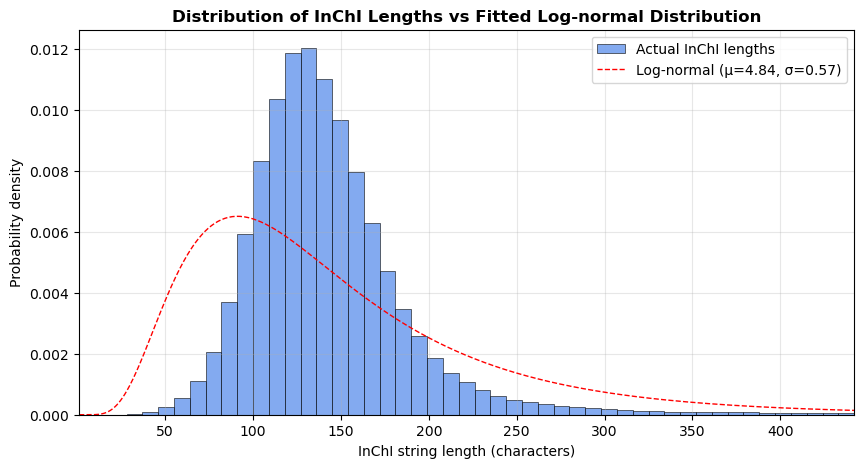

In [15]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import lognorm

# Extract lengths (number of characters) of each InChI string
lengths = db["InChI"].str.len()

# Compute mean and variance
mean_len = lengths.mean()
var_len = lengths.var()
print(f"Mean length: {mean_len:.2f}")
print(f"Variance: {var_len:.2f}")

# Log‑normal 
sigma_sq = np.log(1 + var_len / (mean_len**2))
sigma = np.sqrt(sigma_sq)
mu = np.log(mean_len) - sigma_sq / 2

# Create bins from 1 to 99th percentile, log‑spaced
bins = np.linspace(1, np.percentile(lengths, 99), num=50)

plt.figure(figsize=(10,5))
plt.hist(lengths, bins=bins, density=True, alpha=0.8,
         edgecolor='black', linewidth=0.5,
         color='cornflowerblue', label='Actual InChI lengths')

# X values for smooth curves (linear spaced in log domain)
x_log = np.logspace(0, np.log10(np.percentile(lengths, 99)), 500)

# Log‑normal PDF (red dashed)
pdf_lognorm = lognorm.pdf(x_log, s=sigma, scale=np.exp(mu))
plt.plot(x_log, pdf_lognorm, 'r--', linewidth=1,
         label=f'Log-normal (μ={mu:.2f}, σ={sigma:.2f})')

plt.xlim(1, np.percentile(lengths, 99))
plt.xlabel('InChI string length (characters)')
plt.ylabel('Probability density')
plt.title('Distribution of InChI Lengths vs Fitted Log-normal Distribution', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Figure interpretation**: The distribution shows a clear right-skew, with most molecules concentrated in a relatively narrow range and a progressively decreasing frequency of longer sequences. The long tail reflects the presence of structurally complex molecules, although these represent a small fraction of the dataset. The log-normal curve provides a reasonable approximation of this asymmetry, supporting the interpretation that molecular complexity grows in a non-linear manner. Overall, the data distribution is as expected, with variability primarily driven by a limited number of large outliers.

### Layering and Stereochemistry
Beyond sequence length, it is useful to examine basic structural properties encoded within the InChI strings. InChI representations are inherently hierarchical, with different layers (separated by “/”) encoding connectivity, hydrogen atoms, stereochemistry, and other chemical features.

This analysis focuses on two aspects:

* average number of structural layers, as a proxy for representation complexity, and
* the presence of stereochemical information, which is critical for certain biochemical processes.

In particular, the proportion of molecules containing stereochemistry is monitored, as unexpectedly low values may indicate limitations in the upstream representation or data processing. This observation was further investigated.

In [5]:
def analyze_inchi_structure(inchi):
    return {
        "length": len(inchi),
        "num_layers": inchi.count("/"),
        "has_stereo": int("/t" in inchi or "/m" in inchi or "/b" in inchi or "/s" in inchi),
    }
total = len(db)
num_layers = 0
has_stereo_count = 0
for i in db["InChI"]:
    struct = analyze_inchi_structure(i)
    num_layers += struct["num_layers"]
    has_stereo_count += struct["has_stereo"]

print(f"\n--- InChI Structural Analysis ---")
print(f"Average number of layers: {num_layers / total:.2f}")
print(f"Percentage of InChIs with stereochemistry: {has_stereo_count / total * 100:.2f}%")
print(f"Total stereochemistry entries: {has_stereo_count}")
# Check for @ character
at_count = "".join(db_smiles["SMILES"]).count('@')
print(f"Number of '@' characters found: {at_count}")


--- InChI Structural Analysis ---
Average number of layers: 3.01
Percentage of InChIs with stereochemistry: 0.01%
Total stereochemistry entries: 93
Number of '@' characters found: 0


The analysis shows an extremely low presence of stereochemical information, with only a negligible fraction of InChI strings encoding stereochemistry. This is consistent with the absence of the `@` character in the original SMILES dataset, indicating that chiral centres were not represented. Additionally, stereochemistry associated with double bonds may be partially lost during conversion due to parsing issues with the `\` symbol. Overall, this suggests that stereochemical features are largely underrepresented in the dataset, which may limit the ability of downstream models to capture stereoselective effects.

### Alphabet Size
 The number of unique characters provides a direct indication of the **alphabet size** of the InChI representation, which in this case is relatively small (35 characters). This limited makes it well-suited for subword tokenization methods such as BPE. BPE is justified in this case because it can efficiently capture recurring patterns and substrings within this constrained alphabet, improving representation without requiring a large base vocabulary.

In [6]:
unique_chars = set("".join(db["InChI"]))
print(f"Number of unique characters: {len(unique_chars)}")

Number of unique characters: 35


## Duplicate Analysis: Dataset Redundancy and Consistency

An important aspect of the dataset is the presence of duplicated entries, which can influence both the learning dynamics and the statistical properties of the training data. This analysis quantifies duplication at two levels: the raw SMILES representations and their corresponding InChI encodings. By comparing both, we aim to determine whether redundancy is introduced during the SMILES-to-InChI conversion process or if it is already inherent to the source dataset. Additionally, metrics such as the proportion of unique molecules and the maximum repetition of a single entry provide insight into the overall data distribution and potential biases during pretraining.

In [7]:
def analyze_duplicates(df, df_smiles):
    dup_inchi = df.duplicated(subset="InChI").sum()
    dup_smiles = df_smiles.duplicated(subset="SMILES").sum()

    total = len(df)
    print(f"\n--- Duplicate Analysis ---")
    print(f"InChI duplicates: {dup_inchi} ({dup_inchi/total:.2%})")
    print(f"SMILES duplicates: {dup_smiles} ({dup_smiles/total:.2%})")

    unique_ratio = (total - dup_inchi) / total
    print(f"Unique molecule ratio: {unique_ratio:.4f}")
    print(f"Unique molecules: {total - dup_inchi:,} out of {total:,}")

    print("\n--- Multiplicity ---")
    print(f"Max duplicates (InChI): {df['InChI'].value_counts().max()}")
    print(f"Max duplicates (SMILES): {df_smiles['SMILES'].value_counts().max()}")

analyze_duplicates(db, db_smiles)


--- Duplicate Analysis ---
InChI duplicates: 73565 (4.67%)
SMILES duplicates: 73232 (4.65%)
Unique molecule ratio: 0.9533
Unique molecules: 1,502,162 out of 1,575,727

--- Multiplicity ---
Max duplicates (InChI): 510
Max duplicates (SMILES): 510


The results show a non-negligible level of duplication (~4.7%), with very similar values for both SMILES and InChI representations. This indicates that the vast majority of repeated entries originate from the original SMILES dataset rather than being introduced during conversion. While a small discrepancy between SMILES and InChI duplicates can be observed, this is likely attributable to canonicalization effects, where distinct but equivalent SMILES strings are mapped to the same InChI representation. However, this effect is minimal compared to the overall duplication level, confirming that redundancy is primarily a property of the source data.

### Most Repeated SMILES
This snippet ranks SMILES strings by frequency and prints the most repeated entries, allowing direct inspection of the highest-duplication cases in the dataset. Interestingly, the top occurrences correspond to very large, peptide-like structures, suggesting that certain complex molecules are disproportionately represented.

It is unclear why these specific structures appear so frequently in the source data.

In [8]:
# Inspect a few of the most duplicated SMILES
dup_counts = db_smiles["SMILES"].value_counts()
top_n = 5
print(f"\nTop {top_n} duplicated SMILES:")
for smi, count in dup_counts.head(top_n).items():
    print(f"{count}: {smi}")


Top 5 duplicated SMILES:
510: CSCCC(NC(=O)C(CC(C)C)NC(=O)CNC(=O)C(Cc1ccccc1)NC(=O)C(Cc1ccccc1)NC(=O)C(CCC(N)=O)NC(=O)C(CCC(N)=O)NC(=O)C1CCCN1C(=O)C(CCCCN)NC(=O)C1CCCN1C(=O)C(N)CCCN=C(N)N)C(N)=O
32: CSCCC(NC(=O)C(CCC(N)=O)NC(=O)C(N)Cc1c[nH]c2ccccc12)C(=O)NCC(=O)NC(Cc1c[nH]cn1)C(=O)NC(CO)C(O)=O
30: CCCCCCCCCCCCNC(=O)C1CC(=O)NC(CO)C(=O)NC(Cc2ccc(O)cc2)C(=O)NC(CC(N)=O)C(=O)NCC(=O)NC(CC(N)=O)C(=O)NC(CO)C(=O)NC(CC(N)=O)C(=O)N1
24: CCC(C)C(NC(=O)C(CC(C)C)NC(=O)C(NC(=O)C(N)CCSC)C(C)O)C(=O)NCC(=O)NC(C)C(=O)NC(C)C(=O)NC(Cc1c[nH]cn1)C(=O)NC(CC(N)=O)C(=O)NCC(=O)NC(CO)C(=O)NC(C)C(=O)NC(CCC(N)=O)C(=O)NC(CC(C)C)C(=O)NC(CC(C)C)C(=O)NC(CCCN=C(N)N)C(=O)NC(CCC(N)=O)C(=O)NC(CC(C)C)C(=O)NC(CCCN=C(N)N)C(=O)NCC(=O)NC(CCC(N)=O)C(=O)NC(CC(C)C)C(=O)NCC(=O)N1CCCC1C(=O)N1CCCC1C(=O)NCC(=O)NC(CO)C(=O)NC(CCCN=C(N)N)C(N)=O
21: CCC(C)C(C(CC(=O)N1CCCC1C(OC)C(C)C(=O)NC(Cc1ccccc1)c1nccs1)OC)N(C)C(=O)C(NC(=O)C(C(C)C)N(C)C)C(C)C


## Load ByteLevelBPETokenizer

Loads the pre‑trained tokenizer from the saved `vocab.json` and `merges.txt` files located in the `inchi_tokenizer/` subdirectory.  

The tokenizer was previously trained on a large InChI corpus and will be used to encode InChI strings into token IDs.

In [9]:
from tokenizers import ByteLevelBPETokenizer
import os
# Load the pre-trained ByteLevelBPETokenizer from the specified vocab and merges files
tokenizer = ByteLevelBPETokenizer(
    vocab=os.path.join(script_dir, "inchi_tokenizer", "vocab.json"),
    merges=os.path.join(script_dir, "inchi_tokenizer", "merges.txt"))
print("Loaded ByteLevelBPETokenizer")

Loaded ByteLevelBPETokenizer


## Tokenization of InChI Strings

In order to be able to execute the analysis also on the tokenized strings parallel to the raw InChI, we pre-tokenize all InChI strings in our `main()` function.

This function runs the tokenizer over every InChI in the db. The pre‑trained **ByteLevelBPETokenizer** (loaded from `inchi_tokenizer/vocab.json` and `inchi_tokenizer/merges.txt`) encodes each InChI into a list of token IDs.  

The output is saved as `inchi_tokens.txt` (one line per InChI, space‑separated token IDs).  
Progress is printed every 100,000 entries.  

This is a **one‑time preprocessing step**; subsequent analysis (e.g., token length statistics, verification) reads the cached file rather than re‑encoding the entire corpus.  

The `main()` function is currently commented out in the script. Uncomment it if if is needed to regenerate the tokenized file.

In [10]:
def main():
    output_file = os.path.join(script_dir, "inchi_tokens.txt")
    total = len(db)
    print(f"Starting tokenization of {total} InChIs...")
    with open(output_file, 'w', encoding='utf-8') as f_out:
        for i, inchi in enumerate(db["InChI"]):
            encoded = tokenizer.encode(inchi)
            token_ids = encoded.ids
            f_out.write(" ".join(map(str, token_ids)) + "\n")
            if (i + 1) % 100000 == 0:
                print(f"Processed {i+1}/{total} InChIs")
    print(f"Tokenization complete. Output saved to {output_file}")

with open("inchi_tokens.txt", "r") as f:
    for i, line in enumerate(f):
        if i >= 5:
            break
        print(line.strip())

281 33 21 55 19 39 22 44 26 51 19 71 21 17 22 17 23 19 76 23 44 16 22 44 22 16 21 44 23
281 33 21 55 19 783 24 19 76 21 44 24
281 33 21 55 19 783 24 51 19 71 21 17 22 19 76 22 44 16 21 44 23
281 33 21 55 19 39 22 44 27 582 19 71 23 17 21 17 22 17 24 19 76 24 44 16 21 17 23 44 22
281 33 21 55 19 39 22 44 28 50 22 19 71 23 17 21 17 22 17 24 19 76 21 17 24 44 22


# Tokenized InChI Strings Analysis

Following the generation of tokenized sequences, the next step is to analyse how the tokenizer represents the original InChI strings since this is the data that will be fed into the embedding process. This provides insight into the efficiency and structure of the learned subword vocabulary.

## Tokenizer Efficiency: Characters per Token

To quantify how effectively the tokenizer segments the InChI strings, we compute the average number of characters and tokens per sequence, along with the resulting characters-per-token ratio. This metric reflects how much information is captured per token in the tokenized representation.

A value of 1.35 characters per token indicates a relatively efficient encoding. Unlike natural language, where individual characters carry limited semantic meaning, InChI strings are already highly information-dense at the character level. As a result, fewer characters are needed to form meaningful units, leading to a lower ratio compared to typical text tokenization settings (3-4 characters per token).

In [16]:
# Count total tokens 
total_tokens = 0
with open("inchi_tokens.txt", "r") as f:
    for line in f:
        total_tokens += len(line.split())

# Count total characters
total_chars = 0
with open(inchi_file, "r") as f:
    for line in f:
        total_chars += len(line.strip())

# Compute averages
num_sequences = sum(1 for _ in open(inchi_file))
avg_chars = total_chars / num_sequences
avg_tokens = total_tokens / num_sequences

# Compute ratio
chars_per_token = total_chars / total_tokens

print("\n=== Tokenization Summary ===")
print(f"Average characters per sequence: {avg_chars:.3f}")
print(f"Average tokens per sequence: {avg_tokens:.3f}")
print(f"Characters per token: {chars_per_token:.3f}")


=== Tokenization Summary ===
Average characters per sequence: 148.603
Average tokens per sequence: 109.739
Characters per token: 1.354


## Tokenized Strings Statistics: Sequence Length Distribution
The same percentile-based analysis is now applied to the tokenized sequences, replacing character counts with token counts per sequence. This allows a direct comparison with the raw InChI statistics to assess how tokenization affects sequence length distribution.

In [12]:
# Compute token length percentiles
def compute_token_length_percentiles():
    tokens_file = os.path.join(script_dir, "inchi_tokens.txt")

    lengths = []
    with open(tokens_file, 'r') as f:
        for i, line in enumerate(f):
            token_count = len(line.split())
            lengths.append(token_count)

    # Convert to numpy array for percentile calculation
    lengths_np = np.array(lengths)
    percentiles = [1, 50, 75, 90, 99, 99.9]
    p = np.percentile(lengths_np, percentiles)
    print(f"\n--- Token Length Statistics ---")
    print(f"Total sequences: {len(lengths)}")
    print(f"Mean length: {np.mean(lengths_np):.2f}")
    print(f"Median: {np.median(lengths_np)}")
    print(f"Max length: {np.max(lengths_np)}")
    print(f"Min length: {np.min(lengths_np)}")
    for perc, val in zip(percentiles, p):
        print(f"{perc}th percentile: {val}")

compute_token_length_percentiles()


--- Token Length Statistics ---
Total sequences: 1575727
Mean length: 109.74
Median: 102.0
Max length: 2068
Min length: 11
1th percentile: 55.0
50th percentile: 102.0
75th percentile: 119.0
90th percentile: 142.0
99th percentile: 305.0
99.9th percentile: 844.0


**Interpretation:** The tokenized sequence statistics follow the same overall distribution as the raw InChI lengths, with a consistent reduction in scale across all percentiles. Both the mean (149.6 → 109.7) and median (136 → 102) decrease proportionally, which aligns with the previously observed characters-per-token ratio (~1.35) and confirms that tokenization behaves uniformly across the dataset.

From a modeling perspective, setting a maximum sequence length of **512 tokens** is a well-justified compromise. It fully covers **more than 99% of the dataset without truncation**, while only affecting a very small subset of unusually large molecules. 

In [13]:
tokens_file = os.path.join(script_dir, "inchi_tokens.txt")
db_tokens = pd.read_csv(tokens_file, header=None, names=["Tokens"], sep="\t")
# Extract lengths (number of characters) of each token string
token_lengths = db_tokens["Tokens"].str.split().str.len()

Mean length: 109.74
Variance: 2947.78


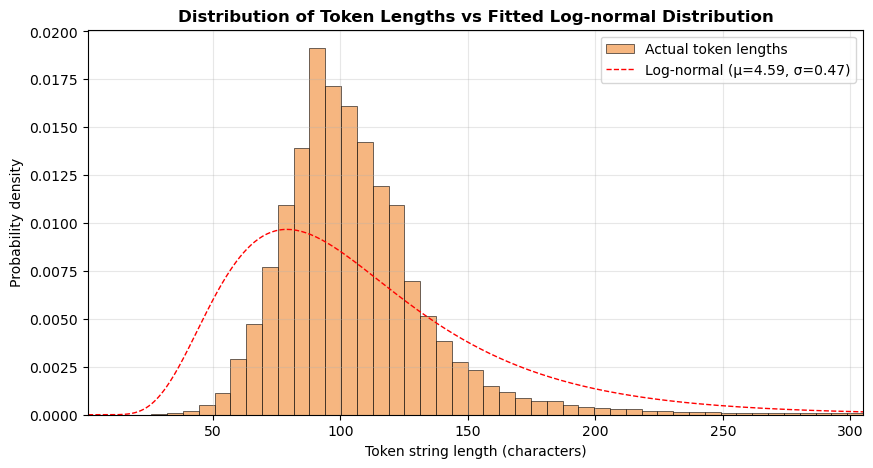

In [18]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import lognorm

# Compute mean and variance
mean_len = token_lengths.mean()
var_len = token_lengths.var()
print(f"Mean length: {mean_len:.2f}")
print(f"Variance: {var_len:.2f}")

# Log‑normal
sigma_sq = np.log(1 + var_len / (mean_len**2))
sigma = np.sqrt(sigma_sq)
mu = np.log(mean_len) - sigma_sq / 2

# Create bins from 1 to 99th percentile
bins = np.linspace(1, np.percentile(token_lengths, 99), num=50)

plt.figure(figsize=(10,5))
plt.hist(token_lengths, bins=bins, density=True, alpha=0.8,
         edgecolor='black', linewidth=0.5,
         color='sandybrown', label='Actual token lengths')

# X values for smooth curves (linear spaced in log domain)
x_log = np.logspace(0, np.log10(np.percentile(token_lengths, 99)), 500)

# Log-normal PDF 
pdf_lognorm = lognorm.pdf(x_log, s=sigma, scale=np.exp(mu))
plt.plot(x_log, pdf_lognorm, 'r--', linewidth=1,
         label=f'Log-normal (μ={mu:.2f}, σ={sigma:.2f})')

plt.xlim(1, np.percentile(token_lengths, 99))
plt.xlabel('Token string length (characters)')
plt.ylabel('Probability density')
plt.title('Distribution of Token Lengths vs Fitted Log-normal Distribution', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Figure Interpretation:** The tokenized lengths follow the same right-skewed pattern observed in the raw InChI strings, with a consistent rescaling of the distribution. This indicates that tokenization preserves the structural characteristics of the data while reducing sequence length, confirming that the transformation does not introduce distortions in the underlying distribution.

## Token Frequency Analysis: Common and Rare Tokens

Frequency of individual tokens within the corpus were analysed using the `collections` library. This allows us to identify highly frequent patterns, as well as rare tokens that appear only a few times.

The very small number of low-frequency tokens (only 36 with fewer than 5 occurrences) indicates that the BPE tokenizer effectively captures recurring substructures.

In [ ]:
from collections import Counter

def token_frequency(inchi_tokens_file):
    counter = Counter()
    with open(inchi_tokens_file) as f: 
        for line in f:
            counter.update(line.split())
    
    def decode_token(t):
        return tokenizer.decode([int(t)])
    
    top = counter.most_common(5)
    bottom = counter.most_common()[-5:]

    print("\nTop 5 tokens:")
    for t, c in top:
        print(f"'{decode_token(t)}' : {c}")

    print("\nBottom 5 tokens:")
    for t, c in bottom:
        print(f"'{decode_token(t)}' : {c}")
    rare_tokens = [t for t, c in counter.items() if c < 5]
    print(f"Number of rare tokens (count < 5): {len(rare_tokens)}")

token_frequency(os.path.join(script_dir, "inchi_tokens.txt"))


Top 5 tokens:
'-' : 34773281
',' : 11058201
')' : 10963604
'(' : 10011912
'H' : 7377962

Bottom 5 tokens:
'FP' : 2
'FNOP' : 2
'676' : 2
'677' : 2
'0' : 1
Number of rare tokens (count < 5): 36


## Outlier analysis: Longest InChI string
As a complementary check, the longest InChI in the dataset was analysed in detail to assess how the tokenizer behaves on extreme cases. 

Character to token ratio shows better than usual compression as expected and in line with the observed trend when comparing percentile statistics between raw InChi and tokenized strings.

In [ ]:
# Max raw string length 
max_str_len = max(db["InChI"].apply(len))
print(f"Longest InChI (characters): {max_str_len}")

# Get the longest InChI string
longest_inchi = db.loc[db["InChI"].str.len().idxmax(), "InChI"]

# Tokenize
encoded = tokenizer.encode(longest_inchi)
token_len = len(encoded.ids)
print(f"Longest InChI tokenized length: {token_len} tokens")
print(f"Sample tokens: {encoded.tokens[:15]}...")  # show first 15
compression_ratio = max_str_len / token_len
print(f"Characters per token ratio: {compression_ratio:.4f}")

Longest InChI (characters): 3915
Longest InChI tokenized length: 2068 tokens
Sample tokens: ['InChI', '=', '1', 'S', '/', 'C', '325', 'H', '387', 'N', '118', 'O', '209', 'P', '29']...
Characters per token ratio: 1.8931


## Verify tokenizer determinism
Before relying on the precomputed tokenized dataset for downstream analysis and model training, it is important to verify that the tokenization process is fully reproducible. This ensures that the stored token IDs correspond exactly to what the tokenizer would generate if applied again under the same configuration. To the date, no inconsistent strings have been observed. No extensive runs have been conducted though, only single string checks.

This function performs a **random‑sampling verification** to ensure that the cached token IDs (`inchi_tokens.txt`) are consistent with the tokenizer’s current behavior.  

- It selects a random InChI from the dataset, retrieves its saved token IDs, and re‑encodes the same InChI using the tokenizer.  
- The two sets of token IDs are compared; if they match, the tokenizer is confirmed to produce deterministic output and the cached file is correctly aligned.  

This check addresses the inherent “black‑box” nature of tokenization pipelines, providing an empirical guarantee that the pre‑processed data can be reliably reused without silent inconsistencies.

In [ ]:
import random
# Verification: compare a random line from saved file with fresh encoding 
# Run as many times as needed to check different random lines
def verify_saved_tokens_random():
    tokens_file = os.path.join(script_dir, "inchi_tokens.txt")
    if not os.path.exists(tokens_file):
        print(f"Error: {tokens_file} not found.")
        return

    # Read all lines to count them and pick a random line
    with open(tokens_file, 'r') as f:
        lines = f.readlines()
    total_lines = len(lines)

    # Pick a random line number (1‑based)
    line_number = random.randint(1, total_lines)
    saved_ids = list(map(int, lines[line_number-1].strip().split()))

    # Get the original InChI from the dataframe (0‑based index)
    original_inchi = db.iloc[line_number-1]["InChI"]

    # Freshly encode the original InChI
    fresh_encoded = tokenizer.encode(original_inchi)
    fresh_ids = fresh_encoded.ids

    # Decode the saved IDs back to a string
    decoded_str = tokenizer.decode(saved_ids)

    print(f"=== Verification for random line {line_number} (of {total_lines}) ===")
    print(f"Original InChI        : {original_inchi}")
    print(f"Decoded from saved IDs: {decoded_str}")
    print(f"Token IDs match       : {saved_ids == fresh_ids}")

    if saved_ids != fresh_ids:
        print("\nMismatch details:")
        print(f"Saved IDs : {saved_ids}")
        print(f"Fresh IDs : {fresh_ids}")
        print(f"Saved tokens : {tokenizer.decode(saved_ids, skip_special_tokens=False)}")
        print(f"Fresh tokens : {tokenizer.decode(fresh_ids, skip_special_tokens=False)}")
        return False
    else:
        print("Verification passed: saved tokens match fresh encoding.")
        return True

verify_saved_tokens_random()

=== Verification for random line 96379 (of 1575727) ===
Original InChI        : InChI=1S/C14H11NO2S/c1-17-11-7-4-5-9(13(11)16)14-15-10-6-2-3-8-12(10)18-14/h2-8,16H,1H3
Decoded from saved IDs: InChI=1S/C14H11NO2S/c1-17-11-7-4-5-9(13(11)16)14-15-10-6-2-3-8-12(10)18-14/h2-8,16H,1H3
Token IDs match       : True
Verification passed: saved tokens match fresh encoding.


True